In [1]:
import yfinance as yf
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
ticker = yf.Ticker('NVDA')
df = ticker.history(start = '2020-01-01',end = '2024-12-31') 
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(1257, 7)
                               Open      High       Low     Close     Volume  \
Date                                                                           
2020-01-02 00:00:00-05:00  5.941886  5.970756  5.891365  5.970756  237536000   
2020-01-03 00:00:00-05:00  5.851046  5.918989  5.826158  5.875186  205384000   
2020-01-06 00:00:00-05:00  5.781859  5.905051  5.755727  5.899825  262636000   
2020-01-07 00:00:00-05:00  5.928197  6.017046  5.883151  5.971253  314856000   
2020-01-08 00:00:00-05:00  5.967021  6.023765  5.926952  5.982451  277108000   

                           Dividends  Stock Splits  
Date                                                
2020-01-02 00:00:00-05:00        0.0           0.0  
2020-01-03 00:00:00-05:00        0.0           0.0  
2020-01-06 00:00:00-05:00        0.0           0.0  
2020-01-07 00:00:00-05:00        0.0           0.0  
2020-01-08 00:00:00-05:00        0.0           0.0  
Open            float64
High            float64
Low       

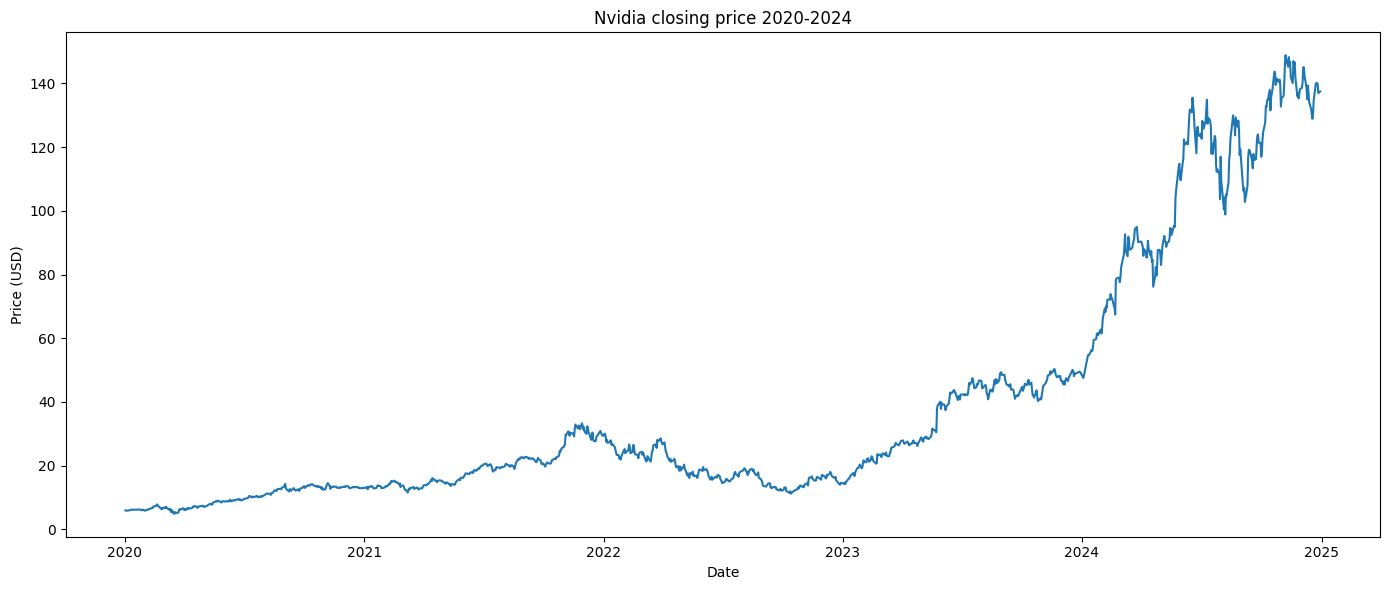

In [3]:
plt.figure(figsize = (14,6))
plt.plot(df.index,df['Close'])
plt.title('Nvidia closing price 2020-2024')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

count    1256.000000
mean        0.003071
std         0.033946
min        -0.184521
25%        -0.015979
50%         0.003297
75%         0.022333
max         0.243696
Name: Daily_Return, dtype: float64


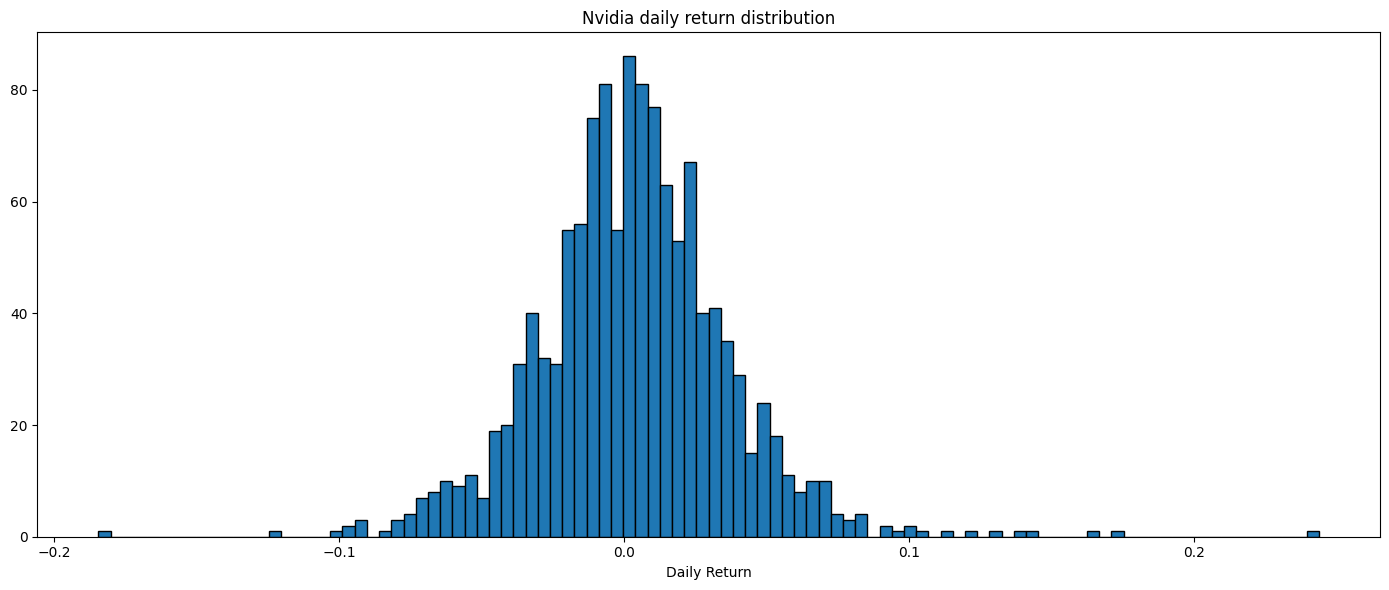

In [4]:
df['Daily_Return'] = df['Close'].pct_change()

print(df['Daily_Return'].describe())
plt.figure(figsize = (14,6))
plt.hist(df['Daily_Return'].dropna(),edgecolor = 'black',bins = 100)
plt.xlabel('Daily Return')
plt.title('Nvidia daily return distribution')
plt.tight_layout()
plt.show()

In [5]:
df['Baseline_pred'] = df['Close'].shift(1)

from sklearn.metrics import mean_absolute_percentage_error

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:].dropna()

baseline_mape = mean_absolute_percentage_error(test_df['Close'],test_df['Baseline_pred']) * 100
print(f'baseline mape is {baseline_mape:.2f}%')

baseline mape is 2.46%


In [8]:
df_features = df.copy()
#lag features past closing prices 
df_features['lag_1'] = df_features['Close'].shift(1)
df_features['lag_2'] = df_features['Close'].shift(2)
df_features['lag_5'] = df_features['Close'].shift(5)
df_features['lag_10'] = df_features['Close'].shift(10)

#rolling mean average price over N days 
df_features['rolling_mean_5'] = df_features['Close'].shift(1).rolling(5).mean()
df_features['rolling_mean_20'] = df_features['Close'].shift(1).rolling(20).mean()
#rolling standard deviation - measures recent volatility 
df_features['rolling_std_5'] = df_features['Close'].shift(1).rolling(5).std()

In [18]:
#price momentum
df_features['momentum_5'] = df_features['Close'].shift(1) / df_features['Close'].shift(6) 
df_features['momentum_10'] = df_features['Close'].shift(1) / df_features['Close'].shift(11) 

#moving average crossover - when short MA croseses over long MA, bullish signal
df_features['ma_crossover'] = df_features['rolling_mean_5'] - df_features['rolling_mean_20']

In [26]:
#volume moving average
df_features['volume_ma_5'] = df_features['Volume'].shift(1).rolling(5).mean()

#volume ratio
df_features['volume_ratio']  = df_features['Volume'] / df_features['volume_ma_5']



                              Volume  volume_ma_5  volume_ratio
Date                                                           
2024-12-16 00:00:00-05:00  237951100  194992200.0      1.220311
2024-12-17 00:00:00-05:00  259410300  204720700.0      1.267143
2024-12-18 00:00:00-05:00  277444500  214598580.0      1.292853
2024-12-19 00:00:00-05:00  209719200  233106440.0      0.899671
2024-12-20 00:00:00-05:00  306528600  243208000.0      1.260356
2024-12-23 00:00:00-05:00  176053500  258210740.0      0.681821
2024-12-24 00:00:00-05:00  105157000  245831220.0      0.427761
2024-12-26 00:00:00-05:00  116205600  214980560.0      0.540540
2024-12-27 00:00:00-05:00  170582600  182732780.0      0.933508
2024-12-30 00:00:00-05:00  167734700  174905460.0      0.959002


In [34]:
df_features['Target'] = df_features['Close'].shift(-1)

df_clean = df_features.dropna()
print(f'original rows: {len(df_features)}')
print(f'clean rows: {len(df_clean)}')
print(f'columns created {df_clean.columns}')
print(df_clean.columns.to_list())

original rows: 1257
clean rows: 1236
columns created Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Daily_Return', 'Baseline_pred', 'lag_1', 'lag_2', 'lag_5', 'lag_10',
       'rolling_mean_5', 'rolling_mean_20', 'rolling_std_5', 'momentum_5',
       'momentum_10', 'ma_crossover', 'volume_ma_5', 'volume_ratio', 'Target'],
      dtype='str')
['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Daily_Return', 'Baseline_pred', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'rolling_mean_5', 'rolling_mean_20', 'rolling_std_5', 'momentum_5', 'momentum_10', 'ma_crossover', 'volume_ma_5', 'volume_ratio', 'Target']


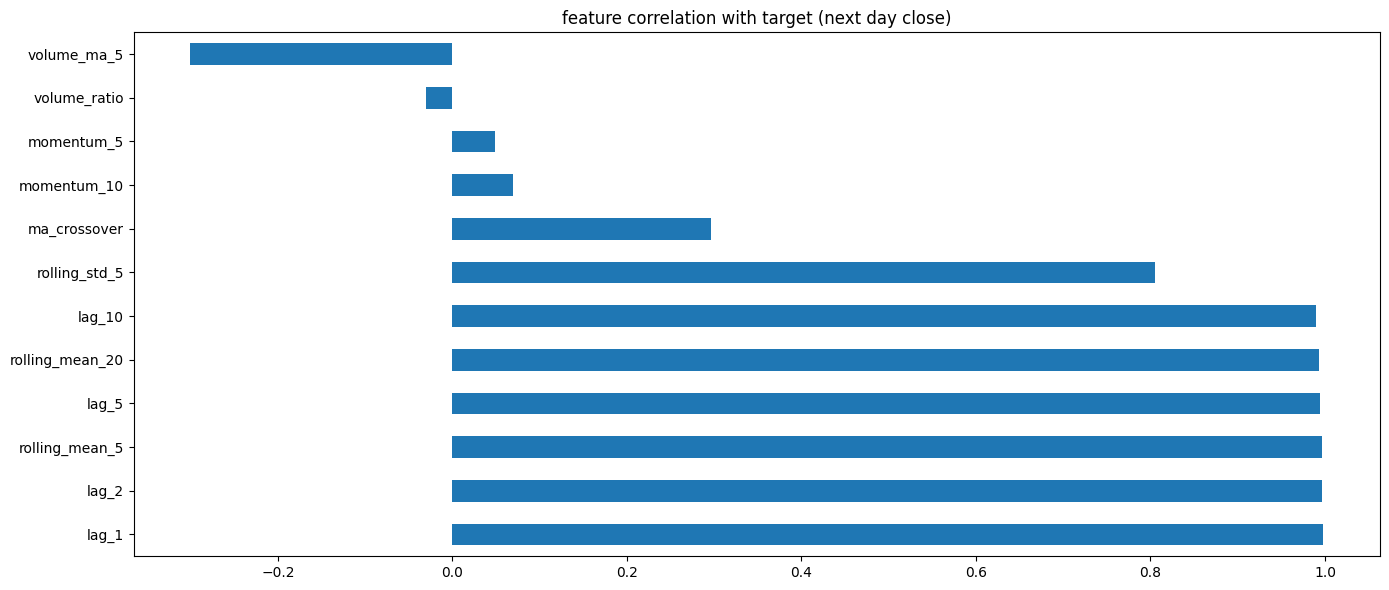

In [47]:
feature_cols = ['lag_1', 'lag_2', 'lag_5', 'lag_10', 'rolling_mean_5', 'rolling_mean_20', 'rolling_std_5', 'momentum_5', 'momentum_10', 'ma_crossover', 'volume_ma_5', 'volume_ratio']

correlations = df_clean[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values(ascending = False)

plt.figure(figsize = (14,6))
correlations.plot(kind = 'barh')
plt.title('feature correlation with target (next day close)')
plt.tight_layout()
plt.show()